In [74]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime

In [75]:
TICKER = "PM"
RISK_FREE = 0.0435

In [76]:
ticker = yf.Ticker(TICKER)
spot = ticker.history(period="1d")["Close"].iloc[-1]
expirations = ticker.options

print(f"\nPrecio spot actual ({TICKER}): ${spot:.2f}")
print(f"Expiraciones disponibles: {list(expirations[:6])} ...")

exp_date = expirations[2]
print(f"Expiración seleccionada: {exp_date}")

chain = ticker.option_chain(exp_date)
calls = chain.calls.copy().reset_index(drop=True)
puts = chain.puts.copy().reset_index(drop=True)

T = (datetime.strptime(exp_date, "%Y-%m-%d") - datetime.now()).days / 365

print(f"Días al vencimiento: {round(T * 365)} | T = {T:.4f} años\n")

mask_c = (calls["strike"] >= spot * 0.90) & (calls["strike"] <= spot * 1.10)
mask_p = (puts["strike"] >= spot * 0.90) & (puts["strike"] <= spot * 1.10)

print("Calls cercanas al spot")
print(calls[mask_c][["strike", "bid", "ask", "impliedVolatility", "volume"]].to_string(index=False))

print("\nPuts cercanas al spot")
print(puts[mask_p][["strike", "bid", "ask", "impliedVolatility", "volume"]].to_string(index=False))


Precio spot actual (PM): $186.93
Expiraciones disponibles: ['2026-05-15', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18'] ...
Expiración seleccionada: 2026-05-29
Días al vencimiento: 16 | T = 0.0438 años

Calls cercanas al spot
 strike  bid  ask  impliedVolatility  volume
  170.0 17.0 19.5           0.552495       1
  175.0 12.3 14.9           0.479619      51
  180.0  8.1 10.3           0.394659       4
  185.0  5.3  6.6           0.348639      67
  190.0  3.0  3.8           0.319953      27

Puts cercanas al spot
 strike  bid  ask  impliedVolatility  volume
  170.0 0.30 0.95           0.387213       3
  175.0 0.40 1.40           0.346198       7
  180.0 1.35 1.85           0.284309     159


In [77]:
# BLACK-SCHOLES

def bs_greeks(S, K, T, r, sigma, opt_type="call"):
    if T <= 0 or sigma <= 0:
        return dict(price=0, delta=0, gamma=0, theta=0, vega=0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if opt_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        theta = (
            -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
            - r * K * np.exp(-r * T) * norm.cdf(d2)
        ) / 365
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        theta = (
            -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
            + r * K * np.exp(-r * T) * norm.cdf(-d2)
        ) / 365

    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100

    return dict(price=price, delta=delta, gamma=gamma, theta=theta, vega=vega)

In [78]:
def nearest(df, target):
    return df.iloc[(df["strike"] - target).abs().argsort()[:1]].iloc[0]

def mid(row):
    bid = row["bid"]
    ask = row["ask"]

    if bid > 0 and ask > 0:
        return (bid + ask) / 2

    return row.get("lastPrice", (bid + ask) / 2)

def show_greeks(label, greeks, sign=1):
    adjusted = {k: sign * v for k, v in greeks.items()}

    print(f"\n[{label}]")
    print(f"Price = ${greeks['price']:.4f}")
    print(f"Delta = {adjusted['delta']:+.4f}")
    print(f"Gamma = {adjusted['gamma']:+.6f}")
    print(f"Theta = {adjusted['theta']:+.6f} por día")
    print(f"Vega  = {adjusted['vega']:+.4f} por 1% de volatilidad")

    return adjusted

def net_g(greeks_list):
    return {k: sum(g[k] for g in greeks_list) for k in greeks_list[0]}

In [79]:
# SELECCIÓN DE CONTRATOS

step = 5.0

# Iron Condor
r_pl = nearest(puts, spot - 2 * step)
r_ps = nearest(puts, spot - step)
r_cs = nearest(calls, spot + step)
r_cl = nearest(calls, spot + 2 * step)

K_pl, m_pl, iv_pl = float(r_pl["strike"]), mid(r_pl), r_pl["impliedVolatility"]
K_ps, m_ps, iv_ps = float(r_ps["strike"]), mid(r_ps), r_ps["impliedVolatility"]
K_cs, m_cs, iv_cs = float(r_cs["strike"]), mid(r_cs), r_cs["impliedVolatility"]
K_cl, m_cl, iv_cl = float(r_cl["strike"]), mid(r_cl), r_cl["impliedVolatility"]

net_ic = (m_ps + m_cs) - (m_pl + m_cl)

print("\n" + "─" * 65)
print("ESTRATEGIA 1: IRON CONDOR")
print(f"Long Put exterior  | Strike: {K_pl:.2f} | Prima: ${m_pl:.2f} | IV: {iv_pl:.1%}")
print(f"Short Put interior | Strike: {K_ps:.2f} | Prima: ${m_ps:.2f} | IV: {iv_ps:.1%}")
print(f"Short Call interior| Strike: {K_cs:.2f} | Prima: ${m_cs:.2f} | IV: {iv_cs:.1%}")
print(f"Long Call exterior | Strike: {K_cl:.2f} | Prima: ${m_cl:.2f} | IV: {iv_cl:.1%}")
print(f"Crédito neto cobrado: ${net_ic:.2f}")

# Protective Put
r_pp = nearest(puts, spot * 0.95)

K_pp = float(r_pp["strike"])
m_pp = mid(r_pp)
iv_pp = r_pp["impliedVolatility"]

print("\n" + "─" * 65)
print("ESTRATEGIA 2: PROTECTIVE PUT")
print(f"Compra de acción {TICKER}: ${spot:.2f}")
print(f"Compra de Put OTM | Strike: {K_pp:.2f} | Prima: ${m_pp:.2f} | IV: {iv_pp:.1%}")
print(f"Costo total de la posición: ${spot + m_pp:.2f}")


─────────────────────────────────────────────────────────────────
ESTRATEGIA 1: IRON CONDOR
Long Put exterior  | Strike: 175.00 | Prima: $0.90 | IV: 34.6%
Short Put interior | Strike: 180.00 | Prima: $1.60 | IV: 28.4%
Short Call interior| Strike: 190.00 | Prima: $3.40 | IV: 32.0%
Long Call exterior | Strike: 190.00 | Prima: $3.40 | IV: 32.0%
Crédito neto cobrado: $0.70

─────────────────────────────────────────────────────────────────
ESTRATEGIA 2: PROTECTIVE PUT
Compra de acción PM: $186.93
Compra de Put OTM | Strike: 180.00 | Prima: $1.60 | IV: 28.4%
Costo total de la posición: $188.53


In [80]:
# GRIEGAS

print("\n" + "=" * 65)
print("GRIEGAS INDIVIDUALES Y NETAS")
print("=" * 65)

print("\nIRON CONDOR")

g_pl = bs_greeks(spot, K_pl, T, RISK_FREE, iv_pl, "put")
g_ps = bs_greeks(spot, K_ps, T, RISK_FREE, iv_ps, "put")
g_cs = bs_greeks(spot, K_cs, T, RISK_FREE, iv_cs, "call")
g_cl = bs_greeks(spot, K_cl, T, RISK_FREE, iv_cl, "call")

p_pl = show_greeks(f"Long Put K={K_pl:.2f}", g_pl, +1)
p_ps = show_greeks(f"Short Put K={K_ps:.2f}", g_ps, -1)
p_cs = show_greeks(f"Short Call K={K_cs:.2f}", g_cs, -1)
p_cl = show_greeks(f"Long Call K={K_cl:.2f}", g_cl, +1)

net_ic_g = net_g([p_pl, p_ps, p_cs, p_cl])

print("\nGriegas netas Iron Condor")
print(f"Delta = {net_ic_g['delta']:+.4f}")
print(f"Gamma = {net_ic_g['gamma']:+.6f}")
print(f"Theta = {net_ic_g['theta']:+.6f}")
print(f"Vega  = {net_ic_g['vega']:+.4f}")

print("\nPROTECTIVE PUT")

g_stk = dict(price=spot, delta=1.0, gamma=0.0, theta=0.0, vega=0.0)
g_pp = bs_greeks(spot, K_pp, T, RISK_FREE, iv_pp, "put")

p_stk = show_greeks(f"Long Stock {TICKER}", g_stk, +1)
p_pp = show_greeks(f"Long Put K={K_pp:.2f}", g_pp, +1)

net_pp_g = net_g([p_stk, p_pp])

print("\nGriegas netas Protective Put")
print(f"Delta = {net_pp_g['delta']:+.4f}")
print(f"Gamma = {net_pp_g['gamma']:+.6f}")
print(f"Theta = {net_pp_g['theta']:+.6f}")
print(f"Vega  = {net_pp_g['vega']:+.4f}")


GRIEGAS INDIVIDUALES Y NETAS

IRON CONDOR

[Long Put K=175.00]
Price = $1.2300
Delta = -0.1654
Gamma = +0.018352
Theta = -0.101450 por día
Vega  = +0.0973 por 1% de volatilidad

[Short Put K=180.00]
Price = $1.6481
Delta = +0.2431
Gamma = -0.028132
Theta = +0.103237 por día
Vega  = -0.1225 por 1% de volatilidad

[Short Call K=190.00]
Price = $3.7923
Delta = -0.4281
Gamma = -0.031340
Theta = +0.162656 por día
Vega  = -0.1536 por 1% de volatilidad

[Long Call K=190.00]
Price = $3.7923
Delta = +0.4281
Gamma = +0.031340
Theta = -0.162656 por día
Vega  = +0.1536 por 1% de volatilidad

Griegas netas Iron Condor
Delta = +0.0776
Gamma = -0.009781
Theta = +0.001786
Vega  = -0.0252

PROTECTIVE PUT

[Long Stock PM]
Price = $186.9300
Delta = +1.0000
Gamma = +0.000000
Theta = +0.000000 por día
Vega  = +0.0000 por 1% de volatilidad

[Long Put K=180.00]
Price = $1.6481
Delta = -0.2431
Gamma = +0.028132
Theta = -0.103237 por día
Vega  = +0.1225 por 1% de volatilidad

Griegas netas Protective Put
Delt

In [81]:
# PAYOFFS

S = np.linspace(spot * 0.70, spot * 1.30, 700)

def c_pnl(S, K, prem, long=True):
    sign = 1 if long else -1
    return sign * (np.maximum(S - K, 0) - prem)

def p_pnl(S, K, prem, long=True):
    sign = 1 if long else -1
    return sign * (np.maximum(K - S, 0) - prem)

pnl_ic = (
    p_pnl(S, K_pl, m_pl, True)
    + p_pnl(S, K_ps, m_ps, False)
    + c_pnl(S, K_cs, m_cs, False)
    + c_pnl(S, K_cl, m_cl, True)
)

max_gain_ic = net_ic
max_loss_ic = -(K_ps - K_pl - net_ic)
be_ic_low = K_ps - net_ic
be_ic_high = K_cs + net_ic

pnl_stk = S - spot
pnl_put_pp = p_pnl(S, K_pp, m_pp, True)
pnl_pp_tot = pnl_stk + pnl_put_pp

max_loss_pp = K_pp - spot - m_pp
be_pp = spot + m_pp

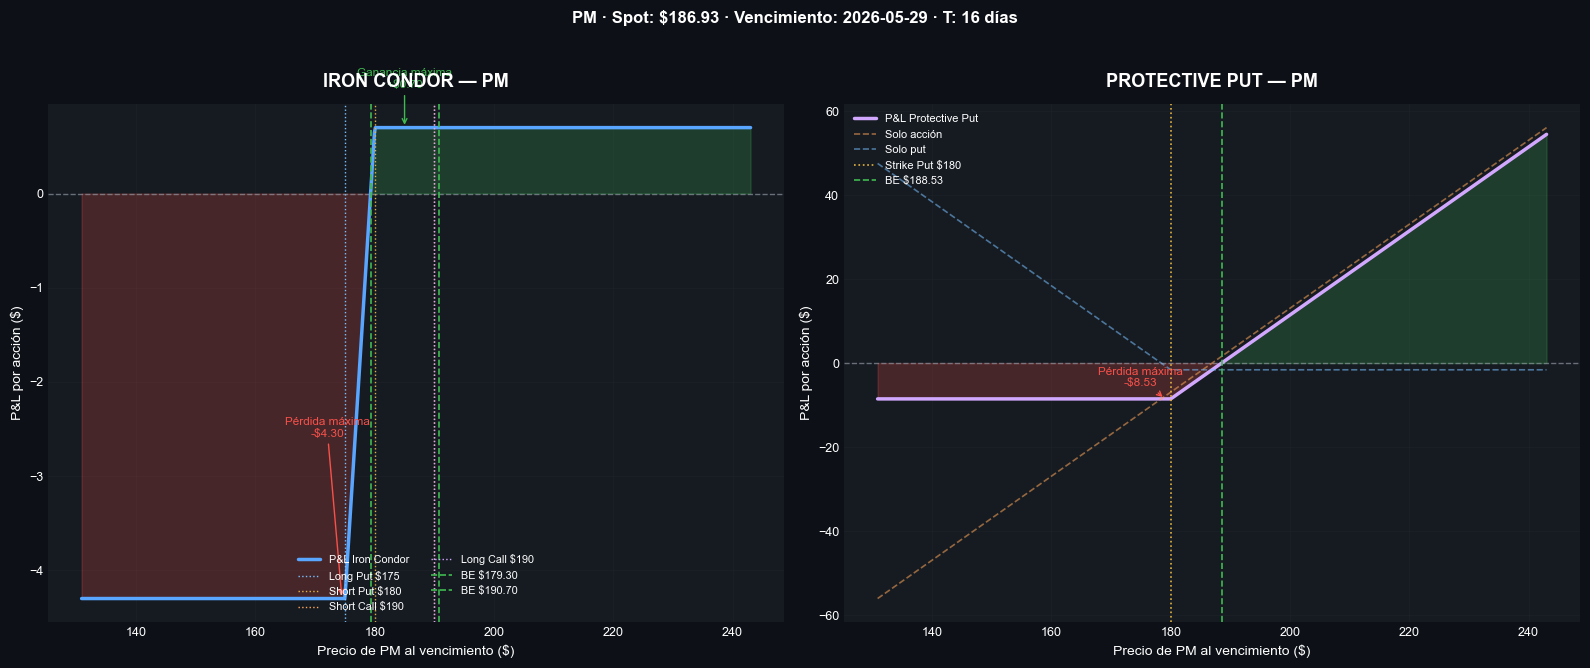

In [82]:
# GRÁFICAS 

C = dict(
    bg="#0d1117",
    panel="#161b22",
    grid="#21262d",
    zero="#8b949e",
    profit="#3fb950",
    loss="#f85149",
    blue="#58a6ff",
    purple="#d2a8ff",
    amber="#e3b341",
    orange="#ffa657",
    cyan="#79c0ff",
    white="white",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(C["bg"])

for ax in axes:
    ax.set_facecolor(C["panel"])
    ax.tick_params(colors=C["white"], labelsize=9)
    ax.xaxis.label.set_color(C["white"])
    ax.yaxis.label.set_color(C["white"])
    ax.title.set_color(C["white"])

    for spine in ax.spines.values():
        spine.set_edgecolor(C["grid"])

    ax.grid(True, color=C["grid"], alpha=0.5, linewidth=0.6)
    ax.axhline(0, color=C["zero"], linewidth=1, linestyle="--", alpha=0.7)

# Iron Condor
ax1 = axes[0]

ax1.plot(S, pnl_ic, color=C["blue"], linewidth=2.5, label="P&L Iron Condor")
ax1.fill_between(S, pnl_ic, 0, where=(pnl_ic >= 0), alpha=0.22, color=C["profit"])
ax1.fill_between(S, pnl_ic, 0, where=(pnl_ic < 0), alpha=0.22, color=C["loss"])

for k, label, color in [
    (K_pl, f"Long Put ${K_pl:.0f}", C["cyan"]),
    (K_ps, f"Short Put ${K_ps:.0f}", C["amber"]),
    (K_cs, f"Short Call ${K_cs:.0f}", C["orange"]),
    (K_cl, f"Long Call ${K_cl:.0f}", C["purple"]),
]:
    ax1.axvline(k, linewidth=1.0, linestyle=":", color=color, label=label)

ax1.axvline(be_ic_low, linewidth=1.2, linestyle="--", color=C["profit"], label=f"BE ${be_ic_low:.2f}")
ax1.axvline(be_ic_high, linewidth=1.2, linestyle="--", color=C["profit"], label=f"BE ${be_ic_high:.2f}")

ax1.annotate(
    f"Ganancia máxima\n+${max_gain_ic:.2f}",
    xy=((K_ps + K_cs) / 2, max_gain_ic),
    xytext=((K_ps + K_cs) / 2, max_gain_ic + abs(max_gain_ic) * 0.6),
    color=C["profit"],
    fontsize=8.5,
    ha="center",
    arrowprops=dict(arrowstyle="->", color=C["profit"]),
)

ax1.annotate(
    f"Pérdida máxima\n-${abs(max_loss_ic):.2f}",
    xy=(K_pl - 0.5, max_loss_ic),
    xytext=(K_pl - 3, max_loss_ic + abs(max_loss_ic) * 0.4),
    color=C["loss"],
    fontsize=8.5,
    ha="center",
    arrowprops=dict(arrowstyle="->", color=C["loss"]),
)

ax1.set_title("IRON CONDOR — PM", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel(f"Precio de {TICKER} al vencimiento ($)")
ax1.set_ylabel("P&L por acción ($)")
ax1.legend(
    fontsize=7.8,
    facecolor="#21262d",
    labelcolor=C["white"],
    edgecolor=C["grid"],
    loc="lower center",
    ncol=2,
)

# Protective Put
ax2 = axes[1]

ax2.plot(S, pnl_pp_tot, color=C["purple"], linewidth=2.5, label="P&L Protective Put")
ax2.plot(S, pnl_stk, color=C["orange"], linewidth=1.2, linestyle="--", alpha=0.55, label="Solo acción")
ax2.plot(S, pnl_put_pp, color=C["cyan"], linewidth=1.2, linestyle="--", alpha=0.55, label="Solo put")

ax2.fill_between(S, pnl_pp_tot, 0, where=(pnl_pp_tot >= 0), alpha=0.22, color=C["profit"])
ax2.fill_between(S, pnl_pp_tot, 0, where=(pnl_pp_tot < 0), alpha=0.22, color=C["loss"])

ax2.axvline(K_pp, color=C["amber"], linewidth=1.2, linestyle=":", label=f"Strike Put ${K_pp:.0f}")
ax2.axvline(be_pp, color=C["profit"], linewidth=1.2, linestyle="--", label=f"BE ${be_pp:.2f}")

ax2.annotate(
    f"Pérdida máxima\n-${abs(max_loss_pp):.2f}",
    xy=(K_pp - 1, max_loss_pp),
    xytext=(K_pp - 5, max_loss_pp + abs(max_loss_pp) * 0.35),
    color=C["loss"],
    fontsize=8.5,
    ha="center",
    arrowprops=dict(arrowstyle="->", color=C["loss"]),
)

ax2.set_title("PROTECTIVE PUT — PM", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel(f"Precio de {TICKER} al vencimiento ($)")
ax2.set_ylabel("P&L por acción ($)")
ax2.legend(
    fontsize=8,
    facecolor="#21262d",
    labelcolor=C["white"],
    edgecolor=C["grid"],
    loc="upper left",
)

plt.suptitle(
    f"{TICKER} · Spot: ${spot:.2f} · Vencimiento: {exp_date} · T: {round(T * 365)} días",
    color=C["white"],
    fontsize=12,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

In [86]:
md = f"""
# {TICKER} | Philip Morris International

**Spot:** ${spot:.2f}  
**Expiración:** {exp_date}  
**Días al vencimiento:** {round(T * 365)}  
**Tasa libre de riesgo:** {RISK_FREE:.1%}

---

## Estrategia 1: Iron Condor

El Iron Condor se construye con cuatro opciones:

| Contrato | Posición | Strike | Prima mid | IV |
|---|---:|---:|---:|---:|
| Put exterior | Long | ${K_pl:.2f} | ${m_pl:.2f} | {iv_pl:.1%} |
| Put interior | Short | ${K_ps:.2f} | ${m_ps:.2f} | {iv_ps:.1%} |
| Call interior | Short | ${K_cs:.2f} | ${m_cs:.2f} | {iv_cs:.1%} |
| Call exterior | Long | ${K_cl:.2f} | ${m_cl:.2f} | {iv_cl:.1%} |

**Crédito neto recibido:** ${net_ic:.2f}

### Resultados principales

| Métrica | Valor |
|---|---:|
| Ganancia máxima | ${max_gain_ic:.2f} |
| Pérdida máxima | ${abs(max_loss_ic):.2f} |
| Breakeven inferior | ${be_ic_low:.2f} |
| Breakeven superior | ${be_ic_high:.2f} |

### Griegas netas

| Griega | Valor |
|---|---:|
| Delta | {net_ic_g["delta"]:+.4f} |
| Gamma | {net_ic_g["gamma"]:+.6f} |
| Theta | {net_ic_g["theta"]:+.6f} |
| Vega | {net_ic_g["vega"]:+.4f} |

El Iron Condor funciona mejor cuando se espera que el precio se mantenga dentro de un rango.  
La estrategia gana principalmente por el paso del tiempo y por una posible caída en la volatilidad implícita.

---

## Estrategia 2: Protective Put

El Protective Put combina una acción comprada con una put comprada para protegerse ante caídas fuertes.

| Contrato | Posición | Strike | Costo |
|---|---:|---:|---:|
| Acción {TICKER} | Long | — | ${spot:.2f} |
| Put OTM | Long | ${K_pp:.2f} | ${m_pp:.2f} |

**Costo total:** ${spot + m_pp:.2f}

### Resultados principales

| Métrica | Valor |
|---|---:|
| Breakeven | ${be_pp:.2f} |
| Pérdida máxima | ${abs(max_loss_pp):.2f} |
| Ganancia máxima | Ilimitada al alza |

### Griegas netas

| Griega | Valor |
|---|---:|
| Delta | {net_pp_g["delta"]:+.4f} |
| Gamma | {net_pp_g["gamma"]:+.6f} |
| Theta | {net_pp_g["theta"]:+.6f} |
| Vega | {net_pp_g["vega"]:+.4f} |

El Protective Put conviene cuando se quiere mantener exposición alcista, pero limitando el riesgo de pérdida.  
La put funciona como un seguro: reduce el riesgo bajista, aunque tiene un costo reflejado en la theta negativa.
"""

display(Markdown(md))


# PM | Philip Morris International

**Spot:** $186.93  
**Expiración:** 2026-05-29  
**Días al vencimiento:** 16  
**Tasa libre de riesgo:** 4.3%

---

## Estrategia 1: Iron Condor

El Iron Condor se construye con cuatro opciones:

| Contrato | Posición | Strike | Prima mid | IV |
|---|---:|---:|---:|---:|
| Put exterior | Long | $175.00 | $0.90 | 34.6% |
| Put interior | Short | $180.00 | $1.60 | 28.4% |
| Call interior | Short | $190.00 | $3.40 | 32.0% |
| Call exterior | Long | $190.00 | $3.40 | 32.0% |

**Crédito neto recibido:** $0.70

### Resultados principales

| Métrica | Valor |
|---|---:|
| Ganancia máxima | $0.70 |
| Pérdida máxima | $4.30 |
| Breakeven inferior | $179.30 |
| Breakeven superior | $190.70 |

### Griegas netas

| Griega | Valor |
|---|---:|
| Delta | +0.0776 |
| Gamma | -0.009781 |
| Theta | +0.001786 |
| Vega | -0.0252 |

El Iron Condor funciona mejor cuando se espera que el precio se mantenga dentro de un rango.  
La estrategia gana principalmente por el paso del tiempo y por una posible caída en la volatilidad implícita.

---

## Estrategia 2: Protective Put

El Protective Put combina una acción comprada con una put comprada para protegerse ante caídas fuertes.

| Contrato | Posición | Strike | Costo |
|---|---:|---:|---:|
| Acción PM | Long | — | $186.93 |
| Put OTM | Long | $180.00 | $1.60 |

**Costo total:** $188.53

### Resultados principales

| Métrica | Valor |
|---|---:|
| Breakeven | $188.53 |
| Pérdida máxima | $8.53 |
| Ganancia máxima | Ilimitada al alza |

### Griegas netas

| Griega | Valor |
|---|---:|
| Delta | +0.7569 |
| Gamma | +0.028132 |
| Theta | -0.103237 |
| Vega | +0.1225 |

El Protective Put conviene cuando se quiere mantener exposición alcista, pero limitando el riesgo de pérdida.  
La put funciona como un seguro: reduce el riesgo bajista, aunque tiene un costo reflejado en la theta negativa.
